# 🧩 DBSCAN


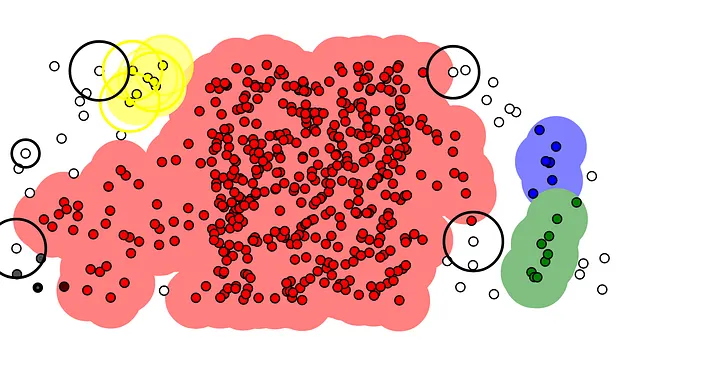

Image from: Sachin Soni



---

## 🎯 Objectius
- Aquest notebook mostra un exemple d'ús del model DBSCAN

## 📦 Dataset Sintètic
- Utilitzarem un dataset sintètic

## 🟦 1. Import Classes

In [9]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set(style="whitegrid", context="notebook")

# Funció per crear punts aproximant una circumferència (amb una mica de soroll gaussià)
def points_in_circle(r, n=100, noise_std=30, noise_mean=0):
    points = [
        (
            math.cos(2 * math.pi / n * x) * r + np.random.normal(noise_mean, noise_std),
            math.sin(2 * math.pi / n * x) * r + np.random.normal(noise_mean, noise_std),
        )
        for x in range(n)
    ]
    return pd.DataFrame(points, columns=["feature1", "feature2"])


## 🟦 1. Creem Datset

In [13]:
# Generem les tres circumferències
df = pd.concat(
    [
        points_in_circle(500, 1000, noise_std=30),
        points_in_circle(300, 700, noise_std=30),
        points_in_circle(100, 300, noise_std=30),
    ],
    ignore_index=True
)

# Afegim soroll aleatori (punts uniformes dins un quadrat)
noise = pd.DataFrame(
    {
        "feature1": np.random.randint(-600, 600, size=300),
        "feature2": np.random.randint(-600, 600, size=300),
    }
)

df = pd.concat([df, noise], ignore_index=True)

df.head()

,feature1,feature2
0,514.619157,32.157896
1,473.611647,13.599426
2,496.205289,31.689483
3,496.454449,-2.124067
4,516.069350,38.850123


## 🟦 2. Visualització inicial (sense clustering)


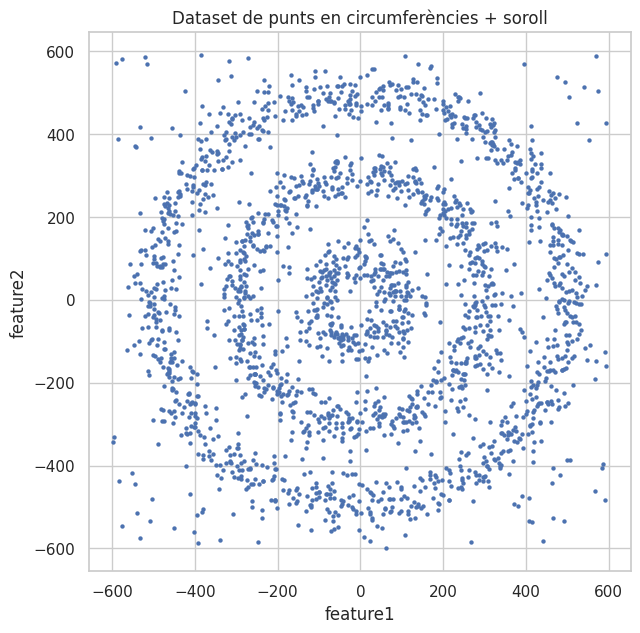

In [11]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x="feature1", y="feature2", s=10, linewidth=0)
plt.axis("equal")
plt.title("Dataset de punts en circumferències + soroll")
plt.show()

## 🟦 3. **K-Means**: Entrenament i visualització



In [19]:
from sklearn.cluster import KMeans

feature_cols = ["feature1","feature2"]
X = df[feature_cols].to_numpy()

kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=10,
    algorithm="lloyd",
    random_state=42
)

kmeans.fit_predict(X)
df['kmeans_cluster']=kmeans.labels_

df.head()


,feature1,feature2,KMeans_labels,kmeans_cluser,kmeans_cluster
0,514.619157,32.157896,1,1,1
1,473.611647,13.599426,1,1,1
2,496.205289,31.689483,1,1,1
3,496.454449,-2.124067,1,1,1
4,516.069350,38.850123,1,1,1


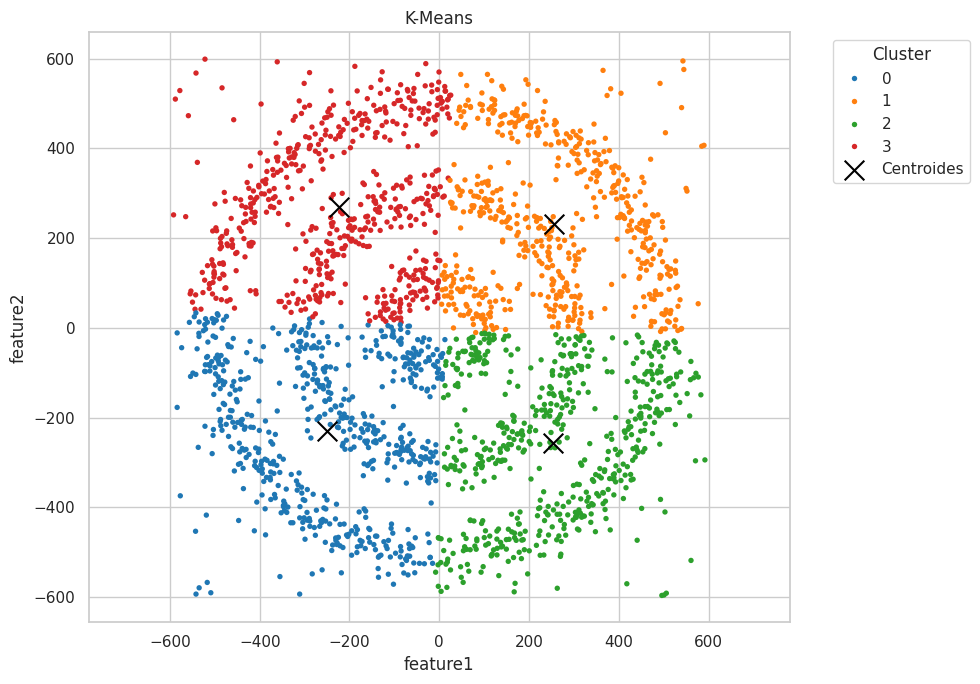

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="feature1",
    y="feature2",
    hue="kmeans_cluster",
    palette="tab10",
    s=15,
    linewidth=0
)

# Pintem els centroides
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=200,
    marker="x",
    label="Centroides"
)

plt.axis("equal")
plt.title("K-Means")
#Llegenda fora del gràfic
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 🟦 4. DBSCAN: Entrenament i visualització

Utilitzarem DBSCAN amb els valors dels hiperparàemtres per defecte:

* epsilon = 0.5
* min_samples = 5

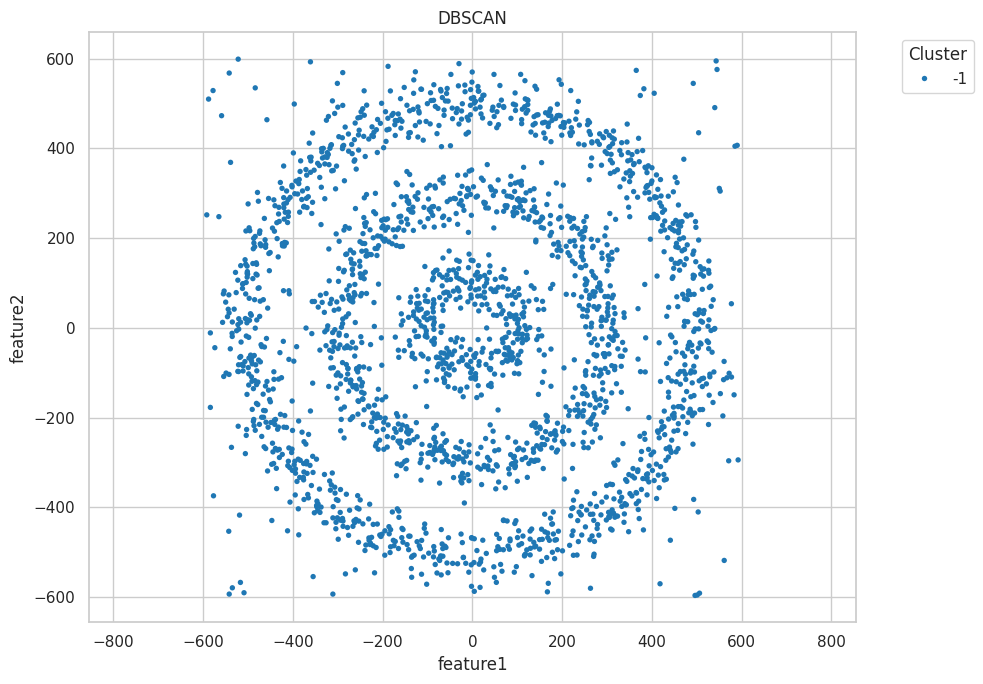

In [35]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN()

dbscan.fit_predict(X)

df['dbscan_cluster']=dbscan.labels_

df.head()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="feature1",
    y="feature2",
    hue="dbscan_cluster",
    palette="tab10",
    s=15,
    linewidth=0
)

plt.axis("equal")
plt.title("DBSCAN")
#Llegenda fora del gràfic
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## 🟦 5. DBSCAN: Cerca d'epsilon

Com hem vist en el gràfic anterior al no tenir un valor d'epsilon i min_points correcte tots el spunts de dades estan el el mateix cluster. Bàsicament és per tot els tracta com a soroll.
Això  és degut a que el valor d'epsilon és molt petit.

Per trobar el valor d'Epsilon utilitzarem el gràfic de k-distance. Per dibuixar un gràfic de distància K, necessitem la distància entre un punt i el seu punt de dades més proper per a tots els punts de dades del conjunt de dades.

Obtenim això utilitzant NearestNeighbors de sklearn.neighbors.

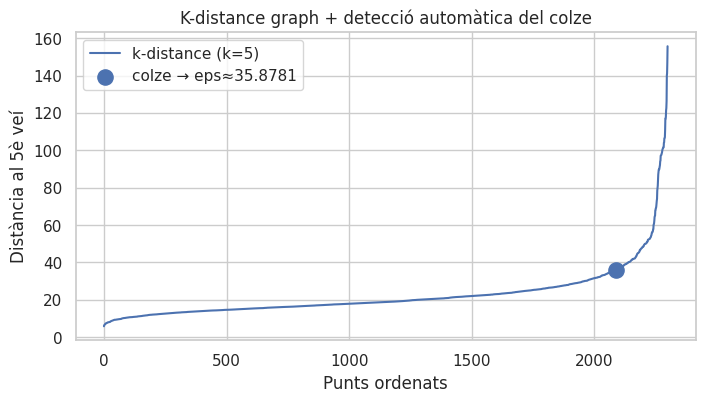

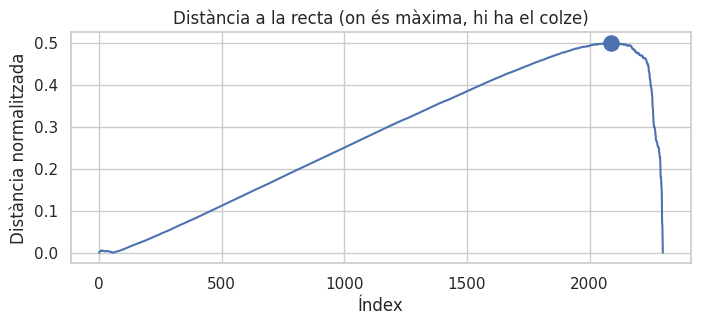

Epsilon suggerit: 35.87805868333647


In [54]:
# Detecció "automàtica" del colze (knee) del K-distance graph
# Sense llibreries externes (només numpy + matplotlib + sklearn)
# Idea pedagògica: el colze és el punt més lluny de la recta que uneix
# el primer i l'últim punt de la corba ordenada.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def kdistance_knee_eps(X, min_samples=5, scale=True, plot=True):
    """
    Retorna:
      - eps_suggested: epsilon suggerit (distància al k-èssim veí al colze)
      - knee_index: índex del colze en la corba ordenada
      - k_dist: array ordenat de distàncies al k-èssim veí

    Mètode:
      1) calculem distància al k-èssim veí (k=min_samples)
      2) ordenem distàncies (k-distances)
      3) normalitzem X i Y a [0,1]
      4) calculem distància perpendicular de cada punt a la recta entre (0, y0) i (1, y1)
      5) el punt amb distància màxima és el "colze"
    """
    X_use = X.copy()

    # 0) Escalat recomanat per DBSCAN
    if scale:
        scaler = StandardScaler()
        X_use = scaler.fit_transform(X_use)

    k = min_samples

    # 1) KNN distances
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X_use)
    distances, _ = nn.kneighbors(X_use)

    # distància al k-èssim veí
    k_dist = np.sort(distances[:, -1])

    # 2) Normalització per fer la geometria independent d'escales
    x = np.linspace(0, 1, len(k_dist))
    y = (k_dist - k_dist.min()) / (k_dist.max() - k_dist.min() + 1e-12)

    # 3) Recta entre primer i últim punt (en espai normalitzat)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    v = p2 - p1
    v_norm = np.linalg.norm(v) + 1e-12

    # 4) Distància perpendicular de cada punt a la recta
    # dist = || (p - p1) x v || / ||v||   (en 2D, el "cross product" és escalar)
    p = np.stack([x, y], axis=1)
    w = p - p1
    cross = np.abs(w[:, 0]*v[1] - w[:, 1]*v[0])
    dist_to_line = cross / v_norm

    knee_index = int(np.argmax(dist_to_line))
    eps_suggested = float(k_dist[knee_index])

    if plot:
        plt.figure(figsize=(8, 4))
        plt.plot(k_dist, label=f"k-distance (k={k})")
        plt.scatter([knee_index], [eps_suggested], s=120, label=f"colze → eps≈{eps_suggested:.4f}")
        plt.title("K-distance graph + detecció automàtica del colze")
        plt.xlabel("Punts ordenats")
        plt.ylabel(f"Distància al {k}è veí")
        plt.legend()
        plt.show()

        # (Opcional, pedagògic) Mostrem també les distàncies a la recta per veure per què surt aquest punt
        plt.figure(figsize=(8, 3))
        plt.plot(dist_to_line)
        plt.scatter([knee_index], [dist_to_line[knee_index]], s=120)
        plt.title("Distància a la recta (on és màxima, hi ha el colze)")
        plt.xlabel("Índex")
        plt.ylabel("Distància normalitzada")
        plt.show()

    return eps_suggested, knee_index, k_dist


# --- Ús ---
eps, idx, kdist = kdistance_knee_eps(X, min_samples=5, scale=False, plot=True)
print("Epsilon suggerit:", eps)


## 🟦 6. DBSCAN -

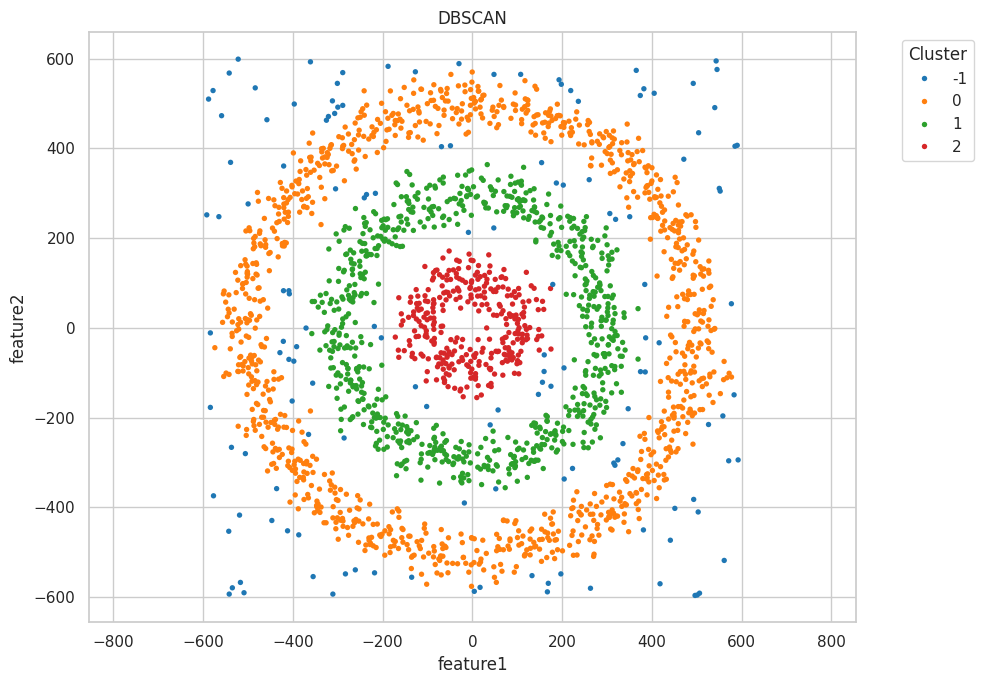

In [55]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=eps,min_samples=7)

dbscan.fit_predict(X)

df['dbscan_cluster']=dbscan.labels_

df.head()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="feature1",
    y="feature2",
    hue="dbscan_cluster",
    palette="tab10",
    s=15,
    linewidth=0
)

plt.axis("equal")
plt.title("DBSCAN")
#Llegenda fora del gràfic
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()